# <span style="color:blue;font-weight:bold;font-size:1.1em">Day 9: Skewed and Bimodal Distributions</span>

As usual, let's initialize the notebook with the following two code blocks the second of which will load our helper functions for exploratory data analysis.

In [171]:
from datascience import *
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import numpy as np
import seaborn as sns
import scipy.stats as stats
from scipy.stats import gaussian_kde

## Read in a CSV data file from the web.
sky = Table.read_table('skyscrapers.csv')
top_movies = Table.read_table('top_movies_2017.csv')
pers = Table.read_table('http://faculty.ung.edu/rsinn/personality.csv')
births = Table.read_table('https://faculty.ung.edu/rsinn/data/baby.csv')
survey = Table.read_table('welcome_survey_v1.csv')

In [172]:
def describe(data, var = None):
  if isinstance(data, Table):
    data = data.column(var)
  names = np.array(["mean", "std", "n", " : : ", "min", "Q1", "median", "Q3", "max", "IQR"])
  values = np.array([round(np.mean(data),1), round(stats.tstd(data),2), len(data) - 1, "", min(data), np.percentile(data, 25), np.median(data), np.percentile(data, 75), max(data), stats.iqr(data)])
  tab = Table().with_columns('Names', names, 'Values', values)  ;  transposed_tab = Table().with_columns( zip(tab.column('Names'), tab.column('Values')) ).show()
  return

def describes(data, num, group):
  dat = data.column(num)  ;  group_var = data.column(group)  ;  groups = np.unique(group_var)  ;  rows = []  ;  tab = Table(["mean", "std", "n", " : : ", "min", "Q1", "median", "Q3", "max", "IQR"])
  for g in groups:
    # Filter data for the current group
    sub_dat = dat[group_var == g]  ;    rows = [g, round(np.mean(sub_dat), 1), round(stats.tstd(sub_dat), 2), len(sub_dat) - 1, min(sub_dat), np.percentile(sub_dat, 25), np.median(sub_dat), np.percentile(sub_dat, 75), max(sub_dat), stats.iqr(sub_dat)]        
    tab = tab.with_row(rows)
  tab.show()
  return

def box(data, num = None, sm = False):
  if isinstance(data, Table):
    df = data.to_df()  ;  sns.boxplot(data=df, y=num, width=0.45, showmeans=sm)  ;
    plots.title(f'Boxplot of {num}')  ;  plots.xticks([], [])  ;  plots.show()  
  else:
    if num == True:
      sm = True  ;  num = 'Variable'
    if num == None:
      num = 'Variable'
    plots.figure(figsize=(6, 6))  ;  plots.boxplot(data, widths = 0.45, showmeans=sm)
    plots.title(f'Boxplot of {num}')  ;  plots.xticks([], [])  ;  plots.show()
  return

def boxes(data, num, cat, sm = False):
  if not isinstance(data, Table):
    print("ERROR: First input must be table name.")
  else:
    df = data.to_df()  ;  sns.boxplot(data=data, x=cat, y=num, width=0.75, showmeans=sm)
    plots.title(f'Boxplot of {num} Grouped by {cat}')  ;  plots.show()
  return

def density(data, num = None):
  if isinstance(data, Table):
    sns.kdeplot( data = data.column(num), bw_method="scott", bw_adjust=0.75, cut=3 )  ;  plots.title(f'Density Plot of {num}')  ;  plots.show()
  else:
    if num == None:
      num = 'Variable'  ;  sns.kdeplot( data = data, bw_method="scott", bw_adjust=0.75, cut=3 )  ;  plots.title(f'Density Plot of {num}')  ;  plots.show()
    else:
      sns.kdeplot( data = data, bw_method="scott", bw_adjust=0.75, cut=3 )  ;  plots.title(f'Density Plot of {num}')  ;  plots.show()
  return

def densities(tab, var, group_var):
  groups = tab.column(group_var) ;  unique_groups = np.unique(groups)  ;  plots.figure()
  for g in unique_groups:
    # Filter data for the current group
    mask = (groups == g)
    x = tab.column(var)[mask]   
    # Calculate KDE for the group subset
    kde = gaussian_kde(x)
    x_grid = np.linspace(x.min() - 1, x.max() + 1, 512)  ;    plots.plot(x_grid, kde(x_grid), label=str(g))   
  plots.title(f'Density Plot of {var} by {group_var}')  ;  plots.xlabel(f'{var}')  ;  plots.ylabel('Density')
  plots.legend()  ;  plots.show()
  return

## <span style="color:blue;font-weight:bold;font-size:1.1em">Bimodal Distributions</span>

What is a <span style="color:red;font-size:1.1em;font-weight:bold">bimodal distribution</span>? At times, the mass of data points builds up around <span style="color:red;font-size:1.1em;font-weight:bold">two specific values</span> rather than one. When the central tendencies of a data set seem to have two different values around which the data collect, we call the result bimodal.

### <span style="color:blue;font-weight:bold;font-size:1.1em">Example 1: Human Body Temperatures</span>

The traditional **normal temperature** for humans is the famed
<center><span style="color:blue;font-weight:bold;font-size:1.25em">$98.6^\circ$</span></center></br>

Arguably, this so-called "normal temperature" isn't either of central tendecies in the data set. Below, conduct an exploratory data analysis upon the **temps** data array to visualize what we mean when we say **bimodal**. We will want to begin with descriptive statistics and a density plot.

In [179]:
temps = make_array(99.2, 98.7, 98.4, 98.6, 98.8, 98.5, 98.3, 98.4, 98.5, 98.2, 98.6, 98.8, 98.6, 99.2, 98.7, 98.5,
                   98.4, 98.5, 99.2, 98.9, 97.9, 98.5, 98.3, 98.2, 98.7, 98.7, 99.2, 98.7, 98.8, 98.2, 99.4, 99.2, 98.3,
                   98.2, 98.8, 97.3, 97.5, 97.6, 97.34, 97.5, 97.1, 97.3, 97.1, 97.6, 97.5, 97.8, 98.1, 97.5, 97.8, 97.6, 
                   97.8, 97.3, 98.2, 98.4, 98.0, 98.1, 97.8, 97.5, 98.0, 98.2, 97.4, 97.9, 97.6, 97.4, 97.9)

In [180]:
descriptive_temps = ...
descriptive_temps

Ellipsis

In [181]:
density_temps = ...

In [182]:
box_plot_temps = ...

In [183]:
box_plot_temps_with_means = ...

### Reporting Out: EDA for Human Body Temperatures

*Write your answer here, replacing this text.*

### <span style="color:blue;font-weight:bold;font-size:1.1em">Example 2: Wait Times at Fast Food Restaurants</span>

Another type of data that often has bimodality is the wait times at a fast food restaurant. For less expensive orders, wait times are generally shorter. For more expensive orders, the wait times may be longer. The more expensive orders often have more total items and more speciality items with longer prep times. The value that splits the data into two groups is often about $6.

Perform an exploratory data analysis below on the wait times at a fast food restaurant.

In [184]:
wait = Table.read_table('wait_times.csv')
wait.show(5)

Amount Spent ($),Wait Time (Minutes)
16.38,5
16.16,6
14.15,4.9
6.89,5.2
5.89,1.9


In [185]:
descriptive_wait = ...
descriptive_wait

Ellipsis

In [186]:
density_wait = ...

In [187]:
box_plot_wait = ...

In [188]:
# Mean Wait Times for Small Orders

wait_less_than_6 = ...
descriptive_wait_less_than_6 = ...
descriptive_wait_less_than_6

Ellipsis

In [189]:
# Mean Wait Times for Large Orders

wait_6_or_more = ...
descriptive_wait_6_or_more = ...
descriptive_wait_6_or_more

Ellipsis

### Reporting Out: EDA for Wait Times at Fast Food Restaurants

*Write your answer here, replacing this text.*

In [190]:
income = Table.read_table('ga_incomes.csv')
income.show(5)

Income,County
143600,Forsyth
88700,Gwinnett
115700,Forsyth
169500,Forsyth
82300,Gwinnett


In [191]:
describe(income, 'Income')

mean,std,n,: :,min,Q1,median,Q3,max,IQR
120027.0,32780.75,99,,66400,90675.0,115650.0,140250.0,201400,49575.0


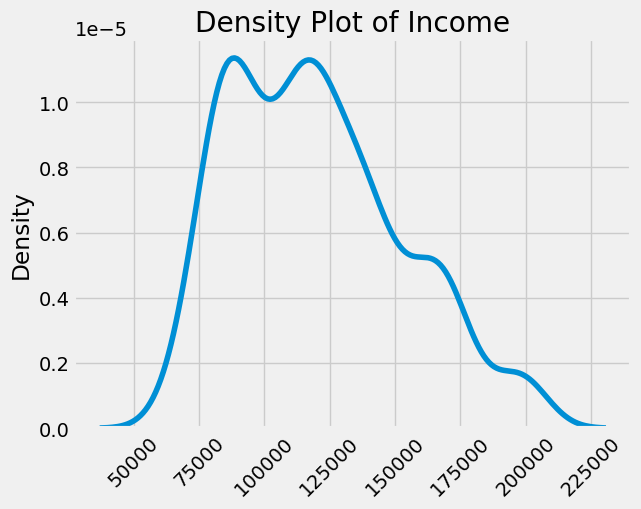

In [192]:
plots.xticks(rotation=45)
density(income, 'Income')

## <span style="color:blue;font-weight:bold;font-size:1.1em">Skewed Distributions</span>

When the **majority of outliers** lie to one side of the distribution, the result is often a quite noticeable 
<center><span style="color:blue;font-weight:bold;font-size:1.25em">skew in the direction of the outliers</span></center></br>

Visually, a skewed distribution occurs when one tail of the histogram or density plot is significantly longer than the other. The three concepts are related:

1. Skew indicates outliers are likely.
2. Outliers indicate skew is likely.
3. A significant difference between the mean and median indicate skew and outliers are likely.

### <span style="color:blue;font-weight:bold;font-size:1.1em">Example 3: BMI for Adult Males</span>

Below, the array data shows the BMIs of adult biological males, a distribution often noted to demonstrate skew. Conduct an **exploratory data analysis** to determine if the data are skewed are not.

In [193]:
bmi_males = make_array( 23.3, 14.1, 17.4, 26.4, 13.2, 24.5, 18, 16.3, 15.1, 13.1, 16.9, 20.9, 21,
    18.8, 19, 16, 15.1, 16.6, 18.2, 19.3, 16.6, 16.3, 16.9, 14.7, 26.7, 16.5, 16.5, 20.5, 20.7, 15.2,
    20.7, 16.7, 20.9, 22.5)

In [194]:
descriptives_bmi = ...
descriptives_bmi

Ellipsis

In [195]:
density_bmi = ...

In [196]:
box_plot_bmi = ...

In [197]:
## PRACTICE: Create a Histogram for this Array Data

hist_bmi = ...

### Reporting Out: BMI for Adult Males

*Write your answer here, replacing this text.*

### <span style="color:blue;font-weight:bold;font-size:1.1em">Example 4: Number of Children per Household</span>

The data below show the number of children per household where the number must be
<center><span style="color:blue;font-weight:bold;font-size:1.1em">greater than zero<span></center></br>

Why? Census and other demographic data specify **family households** as having children in them. Clearly, some families are childless for a period of time, and some couples either choose to not have children or are unable to conceive. However, the definition most commonly used assumes that a family household must have children.

Complete an exploratory data analysis to determine what shape of distribution we have. The data for a typical Georgia community are shown below.

In [198]:
num_children = make_array( 5, 1, 2, 3, 2, 2, 3, 1, 1, 2, 1, 3, 4, 1, 1, 3, 3, 2, 5, 2, 2, 1, 2, 3, 3, 4,
    3, 4, 2, 2, 4, 2, 3, 4, 2, 6, 2, 4, 3, 3, 1, 3, 2, 4, 2, 2, 3, 4, 5, 2, 3, 4, 2, 4, 2)

In [199]:
descriptives_children = ...
descriptives_children

Ellipsis

In [200]:
density_children = ...

In [201]:
box_plot_children = ...

### Reporting Out: Number of Children per Household

*Write your answer here, replacing this text.*

## <span style="color:blue;font-weight:bold;font-size:1.1em">Practice Problems</span>

### <span style="color:blue;font-weight:bold;font-size:1.1em">Example 5: Age of First Time College Students</span>

The age at which most freshmen enter college for the first time is usually 17 to 19 years of age. Howevere, due to students who delay the beginning of university studies due to work, travel, or military service, the distribution is not usually symmetric.

Complete an exploratory data analysis to determine what shape of distribution we have. The data for a university in the state of Kentucky are shown below.

In [202]:
age=make_array(27, 21, 20, 19, 17, 18, 20, 24, 19, 22, 24, 21, 20, 20, 19, 21, 20, 22, 20, 21, 19, 21, 17, 18,
    18, 19, 23, 20, 20, 19, 21, 17, 20, 19, 19, 26, 18, 19, 19, 19, 19, 25, 22, 21, 20, 19, 20, 18, 18, 19, 17, 18,
    18, 19, 18, 19, 18, 18)

In [203]:
descriptives_age = ...
descriptives_age

Ellipsis

In [204]:
density_age = ...

In [205]:
box_plot_age = ...

In [206]:
box_plot_age_with_mean = ...

### Reporting Out: Age of First Time College Students

*Write your answer here, replacing this text.*

### <span style="color:blue;font-weight:bold;font-size:1.1em">Example 6: Grip Strength for Adult Females</span>

The grip strength of a randomn sample of healthy adult human females is neither perfectly normal nor perfectly symmetric. Conduct an exploratory data analysis for the sample of female grip strengths shown below.

In [207]:
grip_strength_kg = make_array(37.2, 29.4, 32.9, 36.9, 28.9, 28.9, 37.1, 33.5, 27.9, 32.4, 27.9, 36.9, 31.1, 21.4, 22.2,
    37.5, 25.4, 31.4, 25.9, 36.6, 36.6, 29.0, 30.3, 23.6, 27.6, 30.5, 24.8, 31.7, 37.3, 28.7, 27.3, 38.3, 29.9, 38, 33.7)

In [208]:
descriptives_grip = ...
descriptives_grip

Ellipsis

In [209]:
density_grip = ...

In [210]:
box_plot_grip = ...

### Reporting Out: Age of First Time College Students

*Write your answer here, replacing this text.*